# Simple Activity Cliffs

Activity Cliffs are important in drug discovery, denoting structural differences between pairs of molecules that exhibit large potencies for their given target. While there are many programs available. Additionally, there are two calcualtions that can be performed that may be informative depending on a drug discovery project.

1. Lipophilic Efficiency (LiPE)
    - Measures whether the potency of a molecule is due to lipophilicity.
        - pIC50 - cLogP
    -  Higher LiPE score is better (typically > 5-6 rage for drugs).
    - [Reference Here](https://pubs.acs.org/doi/10.1021/acs.jmedchem.8b00077)
2. Structure-Activity Landscape Index (SALI)
    $$\text{SALI}_{i,j} = \frac{|A_i - A_j|}{1 - \text{sim}(i,j)}$$

   Where:
  - $A_i, A_j$ = Activity values (e.g. pIC50) for compounds $i$ and $j$
  - $\text{sim}(i,j)$ = Tanimoto Similarity score between compounds $i$ and $j$ (typically ranging from 0 to 1)
  - $|A_i - A_j|$ = Difference in activity values between compounds $i$ and $j$
- Scores potential activity cliffs difference between two molecules.
- The higher the score, the greater/sharper the cliffs.
- [Reference Here](https://pubs.acs.org/doi/10.1021/ci7004093)

Special thanks to Pat Walters, whose blog, [Practical Cheminformatics](http://practicalcheminformatics.blogspot.com/2020/05/using-structure-activity-landscape.html), introduced SALI concept and demoed how to calculate this in Python.

## Import Modules

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem import AllChem, rdMolAlign
from pharmacophore import SAR

## Prepare Dataset

Molecules for this demo will be [Zaprinast](https://en.wikipedia.org/wiki/Zaprinast) and [Sildenafil](https://en.wikipedia.org/wiki/Sildenafil). The latter is more commonly known on teh market as Viagra, while the former is an unsuccessful clinical drug candidate and precursor. Both molecules are Phosphodiesterase 5 (PDE5) inhibitors. Their IC50 values were obtained from [MedChemExpress](https://www.medchemexpress.com).

As the two are structurally related and contain a wide difference in pIC50 values (~2 log difference), they serve as an interesting test for the Structure Activity Relationship (SAR) module.

In [2]:
data = {
    "name": ["zaprinastat", "sildenafil"],
    "smiles": [
        "O=C1C2=C(N=NN2)NC(C3=CC=CC=C3OCCC)=N1",
        "CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O)N4CCN(CC4)C)OCC)C"
    ],
    "activity": ["1,220", "5.22"],
    "units": ["nM", "nM"]
}

df = pd.DataFrame(data=data)
df

,name,smiles,activity,units
0,zaprinastat,O=C1C2=C(N=NN2)NC(C3=CC=CC=C3OCCC)=N1,"1,220",nM
1,sildenafil,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,5.22,nM


### Visualize Molecules
Before we proceed, we will first visualize the molecules used in this demo. A quick visual inspection shows similar core scaffold between the two molecules. These differences could account for their difference potencies in PED5 inhibition.

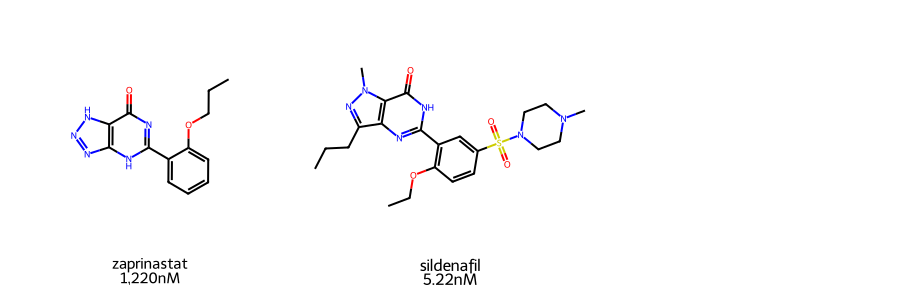

In [3]:
smi_list = df.smiles.tolist()
mols = [Chem.MolFromSmiles(x) for x in smi_list]
name_list = df.name.tolist()
activity_list = df.activity.tolist()
unit_list = df.units.tolist()
label = []
for x, y, z in zip(name_list, activity_list, unit_list):
    label.append(f"{x}\n{y}{z}")

MolsToGridImage(mols=mols, legends=label, subImgSize=(300,300))

## Structure Activity Relationship

To explore the different structures of the two molecules, the **SAR()** class will be instantiated. The **SAR()** class requires a pd.Dataframe of the data with a columns for the structure smiles and activity. The activity is, presumably, the IC50 value for the query moelcule. Internally, the **SAR()** class will convert the activity column into the IC50 range.

In [4]:
# activity needs to be a float
sar = SAR(data=df, smi_col='smiles', act_col='activity')
sar.data

,name,smiles,activity,units,pIC50
0,zaprinastat,O=C1C2=C(N=NN2)NC(C3=CC=CC=C3OCCC)=N1,1220.00,nM,5.913640
1,sildenafil,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,5.22,nM,8.282329


## Calculating LiPE
Once the **SAR()** class is instantiated, the LiPE for each molecule can be calculated. This is done using the **calc_LiPE()** method and is done internally, appending the LiPE score to the DataFrame.

In [5]:
lipe = sar.calc_LiPE()
lipe

,name,smiles,activity,units,pIC50,LiPE
0,zaprinastat,O=C1C2=C(N=NN2)NC(C3=CC=CC=C3OCCC)=N1,1220.00,nM,5.913640,4.416640
1,sildenafil,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,5.22,nM,8.282329,6.671429


## Calculating SALI
Additionally, the SALI score between a part of molecules can be Calculated. This will continue to use the same DataFrame as given and modified with the **calc_LiPE()** method. The **get_sali()** method will reformat the DataFrame. In this demo, the two molecules are combined into a single row containing the relevant information as well as teh calculated Tanimoto Similarity score and SALI score.

In [6]:
sali = sar.get_sali()
sali

Currently only RDKFingerprint will be used by default


,mol_1,mol_2,tanimoto,SALI,smiles_1,smiles_2,pIC50_1,pIC50_2
0,sildenafil,zaprinastat,0.459907,4.377603,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,O=C1C2=C(N=NN2)NC(C3=CC=CC=C3OCCC)=N1,8.282329,5.91364


## Visualizing Activity Cliffs - 2D
The activity cliffs for a pair of molecules can be drawn using the **highlight_cliffs()** method. While a list of smiles can be given, if None is given, then the smiles column given at **SAR()** instantiation will be used.

Internally, the **highlight_cliffs** will identify the Maximum Common Scaffolds (MCS) between the molecules. The different atoms will be identified and highlighted when the molecules are drawn.

Alignment of the 2D molecules will be handled. However, for the demo molecules they do not share an exact core scaffolds. Thus, they are not properly aligned for this example.

Depict error: Substructure match with reference not found.
Cannot Align Molecules.


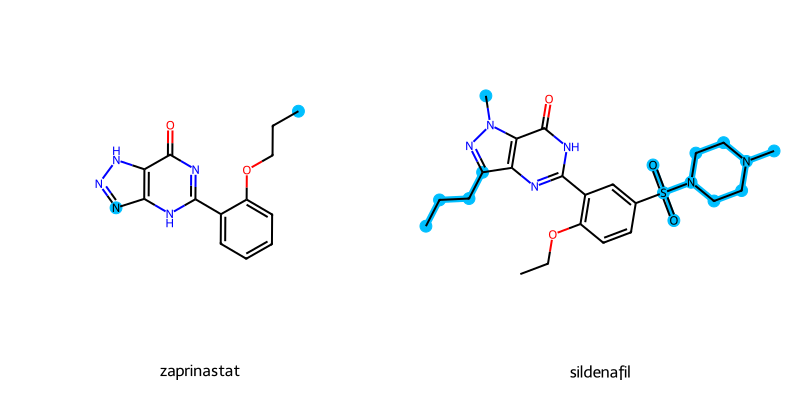

In [7]:
sar.highlight_cliffs(highlight_color="deepskyblue")

## Visualizing Activity Cliffs - 3D

The molecules and their activity cliffs can also be visualized in 3D. For this demo, conformations for the molecules will be generated.

**Note:** The 3D conformations are only needed for this demo. However, it is not strictly needed for 3D visualization. Docking poses or other methods can be used as inputs as well.

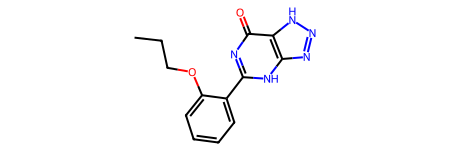

In [8]:
mols = [Chem.AddHs(m) for m in mols]
ps = AllChem.ETKDGv3()
ps.randomSeed = 42
for m in mols:
    AllChem.EmbedMolecule(m,ps)

aligned = []

for x in mols:
    mol_aligned = rdMolAlign.GetO3A(x,mols[0])
    aligned.append(mol_aligned.Align())

 # remove hydrogens for clarity.
mols_noH = [Chem.RemoveHs(m) for m in mols]
mols_noH[0]

### Visualize Activity Cliffs - py3DMol
The molecules can be visualized in 3D using py3DMol. this is done using the **view_cliffs()** method. The molecules will have spheres highlighting the differences as seen with the **highlight_cliffs()** method. The colors correspond to:
- HAcceptor -> Red
- HDonor -> Blue
- Both HAcceptor/Donor -> Magenta
- Hydrophobic -> Green
- Aromatic -> Gold

In [9]:
sar.view_cliffs(mols_noH)

interactive(children=(Dropdown(description='Select:', options=(('Molecule 1', 0), ('Molecule 2', 1)), style=De…

### Visualizing Activity Cliffs - PyMOL
For better manipulation and figure generation, the activity cliff spheres can be exported as a .pml file using the **output_cliffs()** method. This file can then be dragged and dropped to draw the corresponding spheres.

In [10]:
sar.output_cliffs(mols_noH[0],'test.pml')